sample,x1,x2,Label
1,0.552500,-0.158899,0
2,-0.095064,-0.047595,0
3,1.023701,0.151626,0
4,-0.479041,-0.020974,0
5,-0.318535,0.114665,1
6,-1.030674,0.568315,1
7,-0.212346,0.530709,1
8,0.679018,0.284310,1
9,-0.627379,0.106364,0
10,-0.488768,-0.149457,1


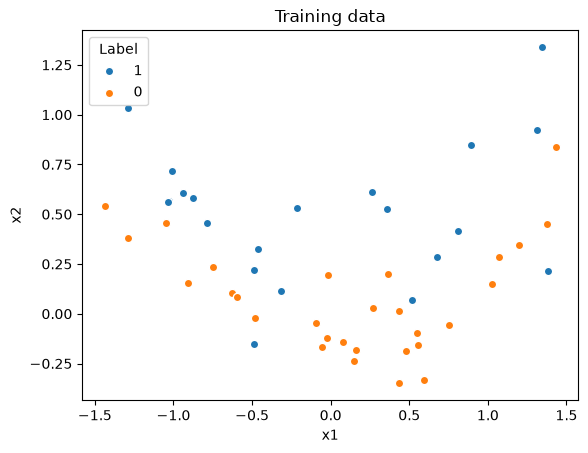

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import copy
import numpy as np

df = pd.read_excel(
    "Assignment2 (team)-dataset.xlsx", header=1, usecols=["sample", "x1", "x2", "Label"]
)
X = torch.tensor(df.drop(columns=["sample", "Label"]).to_numpy(), dtype=torch.float32)
y = torch.tensor(df["Label"].to_numpy(), dtype=torch.float32)
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

display(df.style.hide(axis="index"))

plt.scatter(X[y.bool(), 0], X[y.bool(), 1], label="1", edgecolors="white")
plt.scatter(X[~y.bool(), 0], X[~y.bool(), 1], label="0", edgecolors="white")
plt.title("Training data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(title="Label")
plt.show()

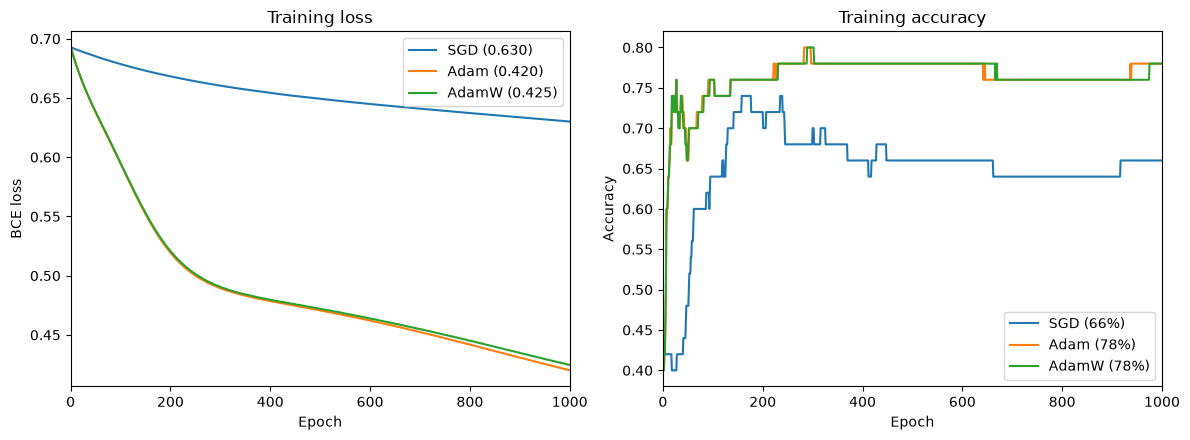

In [61]:
model = nn.Sequential(nn.Linear(2, 3), nn.Tanh(), nn.Linear(3, 1), nn.Sigmoid())
initial_state = copy.deepcopy(model.state_dict())

criterion = nn.BCELoss()

epochs = 1000
model.train()

results = {
    "SGD": {
        "model": (sgd_model := copy.deepcopy(model)),
        "optimizer": optim.SGD(sgd_model.parameters()),
        "loss": [],
        "accuracy": [],
    },
    "Adam": {
        "model": (adam_model := copy.deepcopy(model)),
        "optimizer": optim.Adam(adam_model.parameters()),
        "loss": [],
        "accuracy": [],
    },
    "AdamW": {
        "model": (adamw_model := copy.deepcopy(model)),
        "optimizer": optim.AdamW(adamw_model.parameters()),
        "loss": [],
        "accuracy": [],
    },
}

for optimizer_name in results.keys():
    model = results[optimizer_name]["model"]
    optimizer = results[optimizer_name]["optimizer"]
    for epoch in range(epochs):

        model.train()
        running_loss = 0.0
        for X_batch, y_batch in dataloader:
            optimizer.zero_grad()
            y_hat = model(X_batch).squeeze()
            loss = criterion(y_hat, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * X_batch.size(0)

        model.eval()
        with torch.no_grad():
            accuracy = ((model(X).squeeze() > 0.5) == y).float().mean().item()
        results[optimizer_name]["loss"].append(running_loss / len(dataset))
        results[optimizer_name]["accuracy"].append(accuracy)


fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4.5))

for optimizer_name, r in results.items():
    epoch_range = range(1, epochs + 1)
    ax_loss.plot(
        epoch_range, r["loss"], label=f"{optimizer_name} ({r['loss'][-1]:.3f})"
    )
    ax_acc.plot(
        epoch_range, r["accuracy"], label=f"{optimizer_name} ({r['accuracy'][-1]:.0%})"
    )

ax_loss.set_title("Training loss")
ax_loss.set_ylabel("BCE loss")

ax_acc.set_title("Training accuracy")
ax_acc.set_ylabel("Accuracy")

for ax in (ax_loss, ax_acc):
    ax.set_xlabel("Epoch")
    ax.set_xlim(0, epochs)
    ax.legend()

fig.tight_layout()
plt.show()

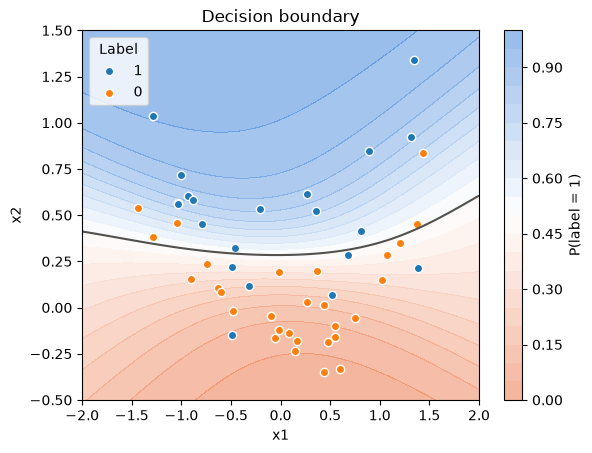

In [ ]:
x1_min, x1_max = -2, 2
x2_min, x2_max = -0.5, 1.5

x1, x2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 1000), np.linspace(x2_min, x2_max, 1000)
)
X_grid = np.stack([x1, x2], axis=-1)  # (100, 100, 2)
model.eval()
with torch.no_grad():
    y_grid = model(torch.tensor(X_grid, dtype=torch.float32)).squeeze(-1).numpy()

cmap = LinearSegmentedColormap.from_list("prob", ["#eb6834", "#ffffff", "#2a78d6"])
heat = plt.contourf(x1, x2, y_grid, levels=np.linspace(0, 1, 21), cmap=cmap, alpha=0.5)
plt.contour(x1, x2, y_grid, levels=[0.5], colors="#52514e", linewidths=1.5)
plt.colorbar(heat, label="P(label = 1)")

plt.scatter(X[y.bool(), 0], X[y.bool(), 1], label="1", edgecolors="white")
plt.scatter(X[~y.bool(), 0], X[~y.bool(), 1], label="0", edgecolors="white")
plt.title("Decision boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(title="Label")
plt.show()